In [33]:
## 필요한 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from keras.models import Sequential
from keras.layers import LSTM, GRU, SimpleRNN, Bidirectional, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.losses import Huber
import joblib

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.options.display.float_format = '{:.2f}'.format

In [2]:
## 칼럼 분석
# datetime : 관측 날짜 (2015.01.01 ~ 2025.06.30, 약 10년)
# sunrise, sunset : 일출 및 일몰 시각 (ISO 8601 형식)
# tempmax / tempmin / temp : 각각 하루의 최고, 최저, 평균 기온 (화씨)
# dew : 이슬점 (이슬이 맺히는 온도)
# humidity : 상대 습도
# precipprob : 강수 확률 (%)
# precipcover : 강수 구역 커버리지 (%)
# preciptype : 강수 형태 (rain)
# precipitation : 총 강수량 (inch)
# windgust / windspeed : 돌풍 속도 및 평균 풍속 (mph)
# winddir : 풍향 (도, 각도)
# sealevelpressure : 해면 기압(hPa)
# cloudcover : 구름이 하늘을 덮는 비율 (운량, %)
# visibility : 가시거리 (miles)
# solarradiation / solarenergy : 일사량 및 태양 에너지
# uvindex : 자외선 지수
# severerisk : 악천후 위험도 지수

In [3]:
## 1. 데이터 로드
df = pd.read_csv("dataset/TIA-WEATHER-DATA.csv")

# 날짜를 인덱스로 변경
df["datetime"] = pd.to_datetime(df["datetime"])
df.set_index("datetime", inplace=True)

# 데이터 구조 확인
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 3468 entries, 2015-01-01 to 2025-06-30
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tempmax           3468 non-null   float64
 1   tempmin           3468 non-null   float64
 2   temp              3468 non-null   float64
 3   dew               3468 non-null   float64
 4   humidity          3468 non-null   float64
 5   precipprob        3468 non-null   int64  
 6   precipcover       3468 non-null   float64
 7   preciptype        1543 non-null   str    
 8   windgust          3468 non-null   float64
 9   windspeed         3468 non-null   float64
 10  winddir           3468 non-null   float64
 11  sealevelpressure  3468 non-null   float64
 12  cloudcover        3468 non-null   float64
 13  visibility        3468 non-null   float64
 14  solarradiation    3468 non-null   float64
 15  solarenergy       3468 non-null   float64
 16  uvindex           3468 non-null   i

In [4]:
## 2. EDA 분석
# 이상치, 결측치, 데이터 분포, 변수 간 상관관계 등을 분석

# 2-1. 결측치 확인
print(df.isnull().sum()[df.isnull().sum() > 0])

preciptype    1925
severerisk    2633
dtype: int64


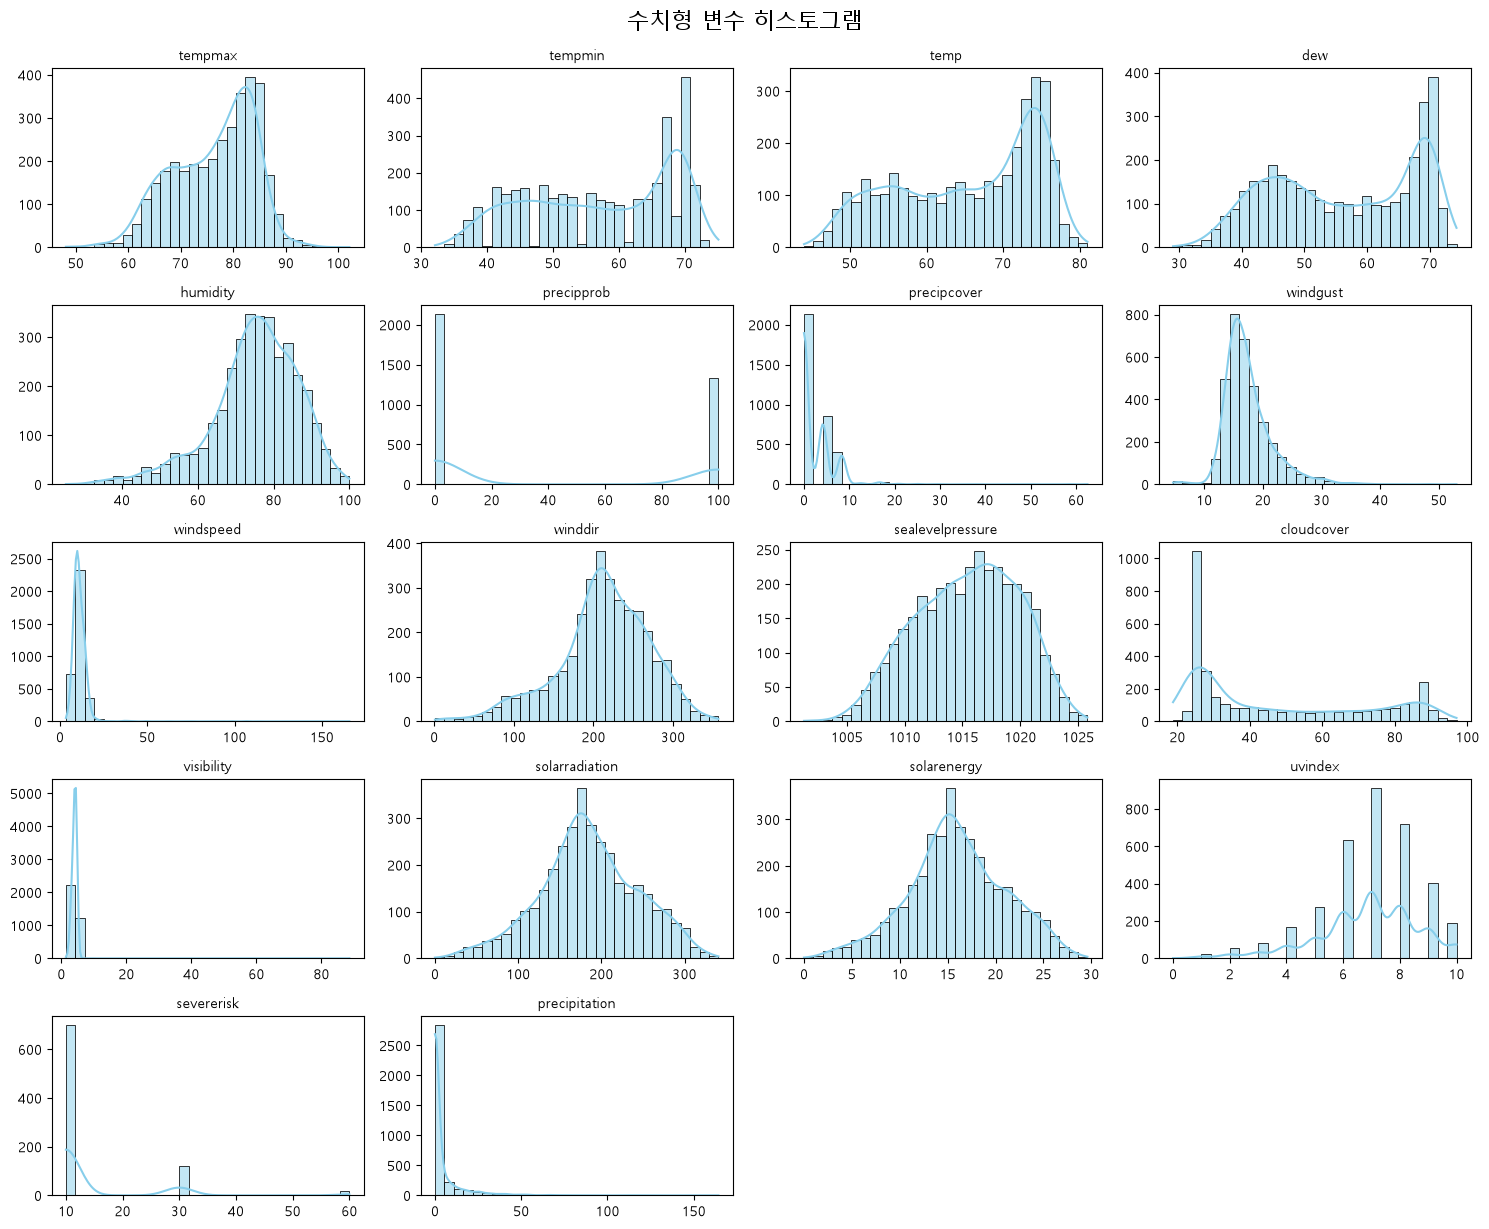

C:\Users\USER\AppData\Local\Temp\ipykernel_1480\2380957661.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cat, x="preciptype", palette="Set2")


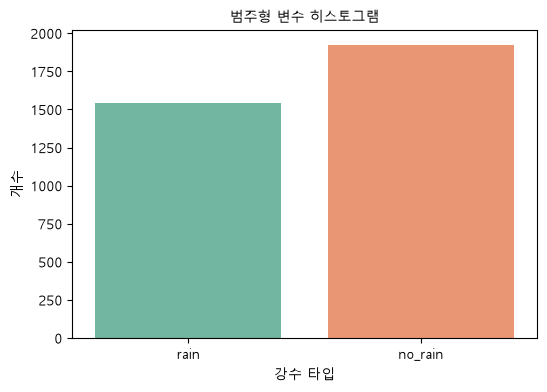

In [5]:
# 2-2. 수치형 데이터와 범주형 데이터로 나눠 시각화하여 분석
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_cols = ["preciptype"] # sunset, sunrise, datetime은 범주의 의미가 없어 제외

# 수치형 데이터
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 4, i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="skyblue")
    plt.title(f"{col}", fontsize=10)
    plt.xlabel("")
    plt.ylabel("")
    
plt.tight_layout()
plt.suptitle("수치형 변수 히스토그램", y=1.02, fontsize=16)
plt.show()

# 범주형 데이터
plt.figure(figsize=(6, 4))
df_cat = df.copy()
df_cat["preciptype"] = df_cat["preciptype"].fillna("no_rain")

sns.countplot(data=df_cat, x="preciptype", palette="Set2")
plt.title("범주형 변수 히스토그램", fontsize=10)
plt.xlabel("강수 타입")
plt.ylabel("개수")
plt.show()

count   3468.00
mean       4.09
std       10.77
min        0.00
25%        0.00
50%        0.00
75%        2.42
max      164.30
Name: precipitation, dtype: float64
무강수 일수: 2107 / 총 3468일


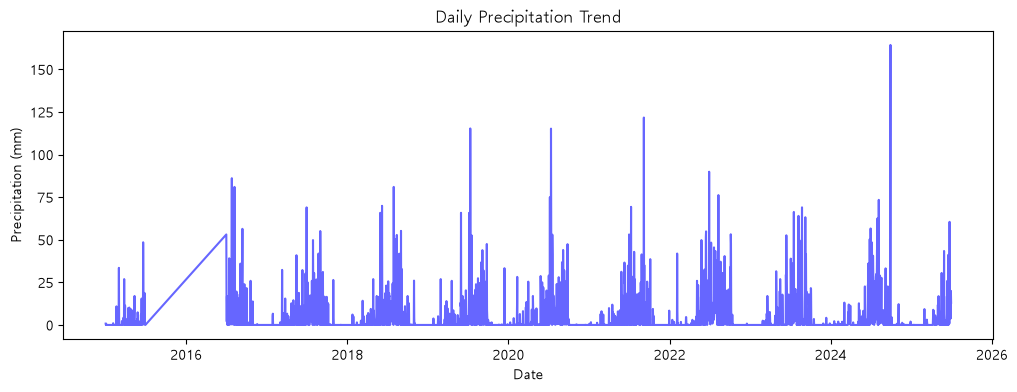

In [6]:
# 타겟 변수 분석
print(df["precipitation"].describe())
zero_rain_count = (df['precipitation'] == 0).sum()
print(f"무강수 일수: {zero_rain_count} / 총 {len(df)}일")

# 강수량 시계열 시각화
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['precipitation'], color='blue', alpha=0.6)
plt.title('Daily Precipitation Trend')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.show()

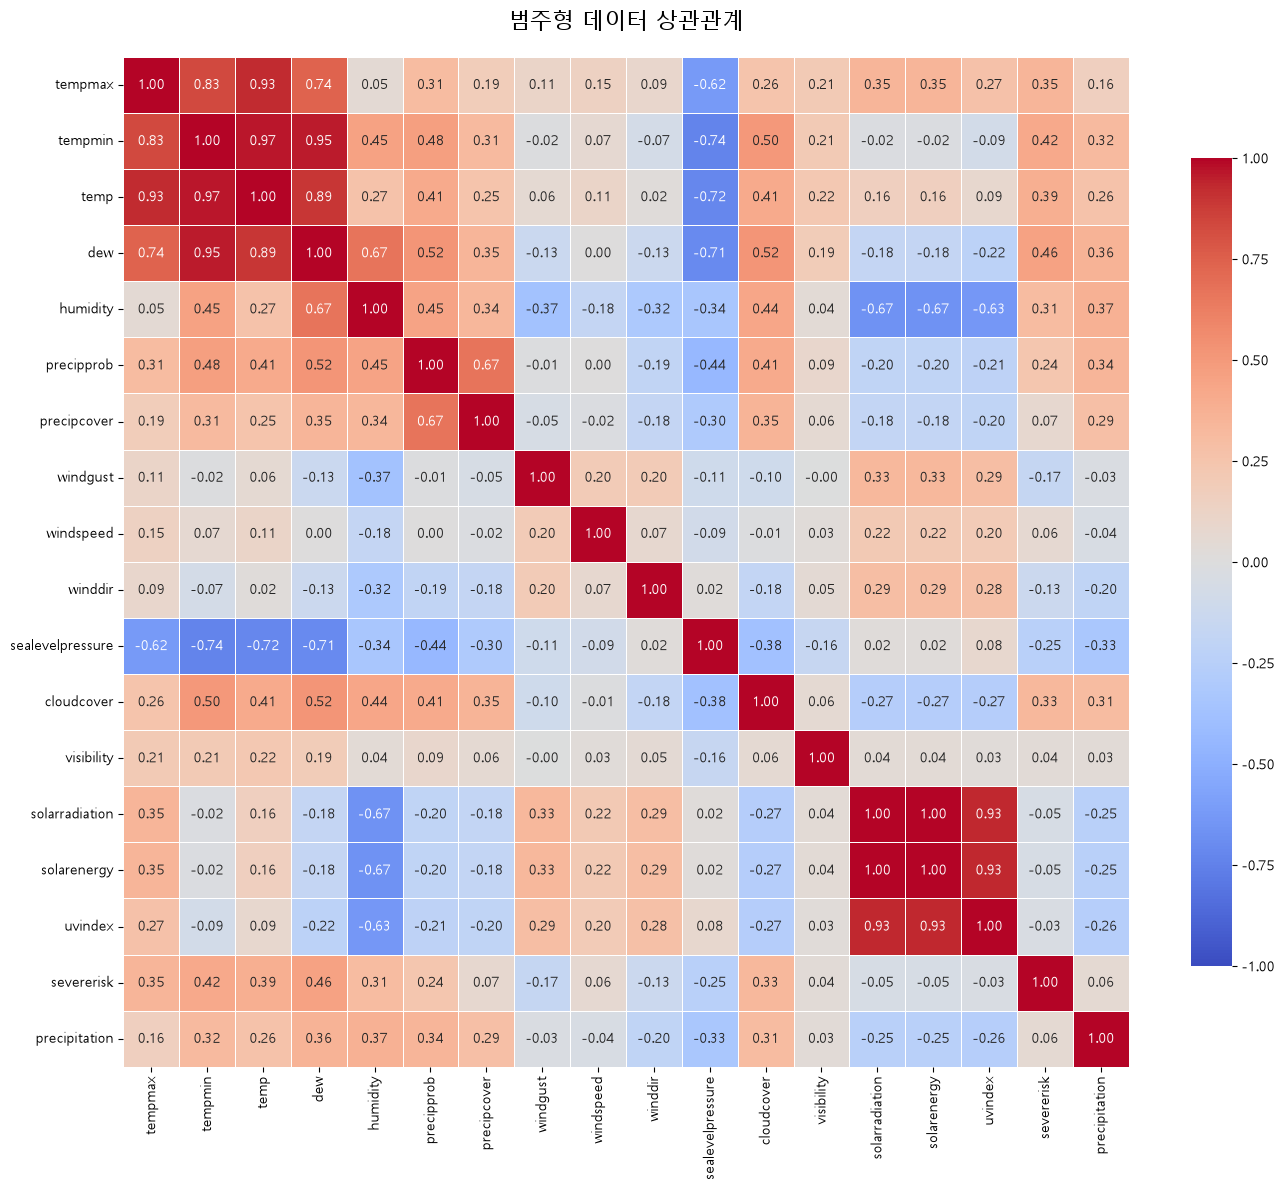

In [7]:
# 2-3. 변수간 상관관계 분석
numeric_df = df.select_dtypes(include=["float64", "int64"])

plt.figure(figsize=(14, 12))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink":.8}
)

plt.title('범주형 데이터 상관관계', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


In [8]:
# < 히트맵 분석 결과 >
# tempmax, tempmin, temp, dew의 연관도가 높아 다중공성선이 의심된다.
# 대표 피처를 하나만 사용하면 될 것 같은데 dew의 경우 타겟과 0.36으로
# 높은 상관관계를 가지고 있기 때문에 제거 대상에서 제외한다.
# 대표 피처는 평균 기온을 나타낼 수 있는 temp를 사용한다.

# solarradiation, solarenergy, uvindex는 연관도가 높아 역시 다중공선성이 의심된다.
# 하지만, 이 피처들의 경우 강수량과는 기상학적으로 관계가 없는 피처로 분석되어 제거 대상에 포함한다.

# sealevelpressure는 음의 연관관계가 높은데
# 기상학적으로 저기압일 때 비가 내리기 때문에 타겟인 강수량과 뚜렷한 음의 상관관계를 가지므로
# 중요한 피처로 제거 대상에서 제외한다.

# humidity는 앞서 제거 대상에 포함한 solarradiation 외 2개의 피처와 음의 연관관계가 높은데
# dew와 마찬가지로 0.37로 전체 피처 중 가장 높은 타겟과의 연관도를 가지고 있기 때문에
# 핵심 피처로 사용해야 하기 때문에 제거 대상에서 제외한다.

# visibility는 강수량과의 상관관계가 0.03으로 거의 0에 수렴한다.
# 비가 오는 날과 안 오는 날의 가시거리가 데이터상에서는 뚜렷하게 잡히지 않는다는 의미고
# 예측에 기여하는 바가 적어 불필요한 노이즈를 발생시킬 우려가 있어 제거 대상에 포함한다.

# severerisk는 강수령과의 상관관계가 0.06으로 낮고
# 결측치를 확인했을 때 60% 이상이 결측치로 확인되어 모두 0으로 채워넣어 학습에 포함시키기에는
# 역시나 왜곡을 발생시킬 우려가 있어 제거 대상에 포함한다.

# 2-4. 불필요한 피처 제거 분석
# sunrise, sunset은 해가 지고 내리는 시간을 기록한 정보인데
# 강수량과는 기상학적으로 비가 오는데 해가 뜨고 지는 건 관계가 없으므로 학습 피처에서 제외한다.
# preciptype은 현재 모델이 강수량을 예측하는 회귀 문제 모델이기도 하며
# 비가 오는 여부는 강수량, 습도, 구름양, 강수 확률, 구름양이 수치적으로 대변해주고 있기 때문에
# 학습 피처에서 제외한다.

### 최종 사용 피처
# temp (기온), dew (이슬점), humidity (상대습도)
# sealevelpressure (해면기압), cloudcover (구름 양), precipprob (강수 확률), precipcover (강수 면적/비율)
# windspeed (풍속), windgust (돌풍), winddir (풍향)

In [9]:
## 3. 데이터 전처리
features = [
    "temp", "dew", "humidity", "sealevelpressure", "cloudcover",
    "precipprob", "precipcover", "windspeed", "windgust", "winddir"
]
target = "precipitation"

data = df[features + [target]].copy()

In [10]:
# 시계열 데이터 분할
total_len = len(data)
train_end = int(total_len * 0.8) # 80% 훈련 데이터, 20% 테스트 데이터

train_df = data.iloc[:train_end]
test_df = data.iloc[train_end:]

print(f"Total 데이터 크기: {len(data)}일")
print(f"Train 데이터 크기: {len(train_df)}일")
print(f"Test 데이터 크기: {len(test_df)}일")

Total 데이터 크기: 3468일
Train 데이터 크기: 2774일
Test 데이터 크기: 694일


In [11]:
# 데이터 스케일링 (데이터 누수 방지)
# 타겟 데이터의 원래 단위의 값으로 복원하기 위해 피처와 타켓의 스케일러를 각각 따로 사용한다.
# 예측 값을 뱉었을 때 실제 단위 값으로 변환하여 비교하기 위함 
scaler_feature = MinMaxScaler()
scaler_target = MinMaxScaler()

train_scaled_features = scaler_feature.fit_transform(train_df[features])
train_scaled_target = scaler_target.fit_transform(train_df[[target]])

test_scaled_features = scaler_feature.transform(test_df[features])
test_scaled_target = scaler_target.transform(test_df[[target]])

In [12]:
# 슬라이딩 윈도우 시퀀스 데이터 생성
# RNN, LSTM, BiLSTM, GRU 모델은 (샘플수, 타임스텝, 피처수) 형태의 3차원 텐서로
# 입력을 받기 때문에 맞춤 형태로 입력 데이터를 가공해야 한다.

# 샘플 수 : 모델이 한 번에 묶어서 학습하는 샘플의 수
# 타임 스텝 : 과거 데이터를 얼마나 거슬러 올라가서 볼 것인지에 대한 lookback
# 피처 수 : 모델이 참고하는 독립 변수의 개수 (현재 모델은 10개)
def create_sequences(features_data, target_data, lookback=14): # 14일치 과거 데이터를 참고 (기본값)
    X, y = [], []
    for i in range(lookback, len(features_data)):
        X.append(features_data[i - lookback:i])
        y.append(target_data[i])
    return np.array(X), np.array(y)

LOOKBACK_DAYS = 14
X_train, y_train = create_sequences(train_scaled_features, train_scaled_target, LOOKBACK_DAYS)
X_test, y_test = create_sequences(test_scaled_features, test_scaled_target, LOOKBACK_DAYS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (2760, 14, 10), y_train: (2760, 1)
X_test: (680, 14, 10), y_test: (680, 1)


In [13]:
## 4. 모델 정의 (RNN, LSTM, BiLSTM, GRU)
# 모델 4개를 비교하여 성능이 우수한 모델을 baseline 모델로 선정
# 기초 성능을 확인하기 위해 단순 구조로 모델 정의
def build_model(model_type, input_shape):
    model = Sequential()
    
    if model_type == "RNN":
        model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    elif model_type == "LSTM":
        model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    elif model_type == "BiLSTM":
        model.add(Bidirectional(LSTM(64, input_shape=input_shape, return_sequences=False)))
    elif model_type == "GRU":
        model.add(GRU(64, input_shape=input_shape, return_sequences=False))

    model.add(Dropout(0.2)) # 과적합 방지
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [14]:
### 5. 모델 학습
model_names = ["RNN", "LSTM", "BiLSTM", "GRU"]
results = {}
predictions = {}

input_shape = (X_train.shape[1], X_train.shape[2])
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

for name in model_names:
    print(f"\n=== [{name}] 모델 학습 시작 ===")
    model = build_model(name, input_shape)
    
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1 # 학습 로그 안나오게
    )
    
    ## 6. 모델 평가
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[name] = {"Loss(MSE)": loss, "MAE": mae}
    
    # 새로운 값 예측
    pred_scaled = model.predict(X_test, verbose=0)
    predictions[name] = scaler_target.inverse_transform(pred_scaled)
    print(f"[{name}] 평가 완료 - Loss(MSE): {loss:.4f}, MAE: {mae:.4f}")


=== [RNN] 모델 학습 시작 ===
Epoch 1/30


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0239 - mae: 0.1047 - val_loss: 0.0093 - val_mae: 0.0496
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - mae: 0.0509 - val_loss: 0.0091 - val_mae: 0.0396
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0069 - mae: 0.0427 - val_loss: 0.0074 - val_mae: 0.0417
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0067 - mae: 0.0423 - val_loss: 0.0078 - val_mae: 0.0403
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - mae: 0.0418 - val_loss: 0.0075 - val_mae: 0.0417
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - mae: 0.0397 - val_loss: 0.0072 - val_mae: 0.0416
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - mae: 0.0389 - val_loss: 0.0071 - val_mae: 0.0447
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0062 - mae: 0.0405 - val_loss: 0.0078 - val_mae: 0.0404
Epoch 9/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 - mae: 0.0390 - va

c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0080 - mae: 0.0523 - val_loss: 0.0077 - val_mae: 0.0446
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - mae: 0.0419 - val_loss: 0.0071 - val_mae: 0.0472
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - mae: 0.0407 - val_loss: 0.0074 - val_mae: 0.0416
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - mae: 0.0386 - val_loss: 0.0084 - val_mae: 0.0394
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - mae: 0.0401 - val_loss: 0.0075 - val_mae: 0.0396
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - mae: 0.0389 - val_loss: 0.0072 - val_mae: 0.0413
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - mae: 0.0383 - val_loss: 0.0070 - val_mae: 0.0425
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0387 - val_loss: 0.0074 - val_mae: 0.0393
Epoch 9/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - mae: 0.0381 - va

c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0083 - mae: 0.0557 - val_loss: 0.0076 - val_mae: 0.0409
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - mae: 0.0427 - val_loss: 0.0072 - val_mae: 0.0425
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - mae: 0.0434 - val_loss: 0.0070 - val_mae: 0.0438
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - mae: 0.0411 - val_loss: 0.0071 - val_mae: 0.0426
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0405 - val_loss: 0.0071 - val_mae: 0.0449
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - mae: 0.0403 - val_loss: 0.0075 - val_mae: 0.0410
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0402 - val_loss: 0.0075 - val_mae: 0.0401
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - mae: 0.0393 - val_loss: 0.0075 - val_mae: 0.0396
[BiLSTM] 평가 완료 - Loss(MSE): 0.0080, MAE: 0.0380

=== [GRU] 모델 학습 시작 ===
Epoch 1/30


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0130 - mae: 0.0743 - val_loss: 0.0076 - val_mae: 0.0430
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072 - mae: 0.0495 - val_loss: 0.0075 - val_mae: 0.0411
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - mae: 0.0430 - val_loss: 0.0069 - val_mae: 0.0432
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - mae: 0.0413 - val_loss: 0.0072 - val_mae: 0.0424
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - mae: 0.0415 - val_loss: 0.0069 - val_mae: 0.0451
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - mae: 0.0408 - val_loss: 0.0081 - val_mae: 0.0391
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - mae: 0.0391 - val_loss: 0.0070 - val_mae: 0.0523
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - mae: 0.0393 - val_loss: 0.0069 - val_mae: 0.0424
[GRU] 평가 완료 - Loss(MSE): 0.0078, MAE: 0.0373


[모델 최종 비교]
        Loss(MSE)  MAE
GRU          0.01 0.04
LSTM         0.01 0.04
BiLSTM       0.01 0.04
RNN          0.01 0.04


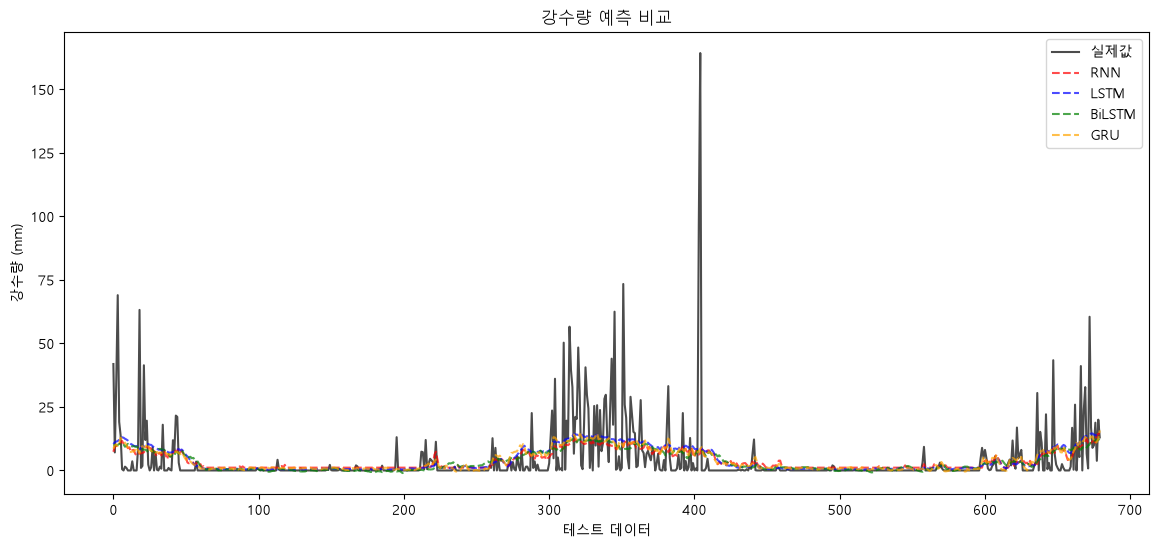

In [15]:
# 결과 요약 및 시각화 비교
results_df = pd.DataFrame(results).T
print("[모델 최종 비교]")
print(results_df.sort_values(by="Loss(MSE)"))

y_test_real = scaler_target.inverse_transform(y_test)

plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="실제값", color="black", linewidth=1.5 ,alpha=0.7)

colors = {"RNN": "red", "LSTM": "blue", "BiLSTM": "green", "GRU": "orange"}
for name in model_names:
    plt.plot(predictions[name], label=name, linestyle="--", alpha=0.7, color=colors[name])

plt.title("강수량 예측 비교")
plt.xlabel("테스트 데이터")
plt.ylabel("강수량 (mm)")
plt.legend()
plt.show()

In [16]:
# 전체적으로 비가 오지 않는 날은 예측을 잘 하고 있는데
# 폭우가 오는 날이나 비가 오는 날엔 오차가 큰 것을 알 수 있다.
# 이는 현재 데이터의 7~80%가 비가 오지 않을 때 데이터이기 때문이다.

# 4개의 모델 모두 성능이 비슷하게 나왔기 때문에 베이스라인을 정하기 어렵다.
# 따라서 학습 시 손실 함수 변경 (mse -> mae)을 해보고 베이스라인을 정한 뒤
# 베이스라인에서 모델을 고도화 시키고 만약, 성능 개선이 없다면 아래의 방법을 채택하려고 한다.

# - 강수량 데이터에서 0 비율 점검하여 타겟 데이터에 np.log1p를 취하여 데이터 분포 조정
# - 파이프라인 (분류 + 회귀) 도입 검토

In [17]:
## 학습 시 손실 함수 변경 (mae)
def build_model_v2(model_type, input_shape):
    model = Sequential()
    
    if model_type == "RNN":
        model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    elif model_type == "LSTM":
        model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    elif model_type == "BiLSTM":
        model.add(Bidirectional(LSTM(64, input_shape=input_shape, return_sequences=False)))
    elif model_type == "GRU":
        model.add(GRU(64, input_shape=input_shape, return_sequences=False))

    model.add(Dropout(0.2)) # 과적합 방지
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    
    model.compile(optimizer="adam", loss="mae", metrics=["mse", "mae"])
    return model

In [18]:
# 바뀐 손실 함수로 모델 학습
model_names = ["RNN", "LSTM", "BiLSTM", "GRU"]
results = {}
predictions = {}

input_shape = (X_train.shape[1], X_train.shape[2])
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

for name in model_names:
    print(f"\n=== [{name}] 모델 학습 시작 ===")
    model = build_model_v2(name, input_shape)
    
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0 # 학습 로그 안나오게
    )
    
    ## 6. 모델 평가
    eval_results = model.evaluate(X_test, y_test, verbose=0)
    loss_mae = eval_results[0]
    mse_val = eval_results[1]
    mae_val = eval_results[2]
    
    results[name] = {"Loss(MAE)": loss_mae, "MSE": mse_val, "MAE": mae_val}
    
    # 새로운 값 예측
    pred_scaled = model.predict(X_test, verbose=0)
    predictions[name] = scaler_target.inverse_transform(pred_scaled)
    print(f"[{name}] 평가 완료 - Loss(MAE): {loss_mae:.4f}, MSE: {mse_val:.4f}, MAE: {mae_val:.4f}")


=== [RNN] 모델 학습 시작 ===


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[RNN] 평가 완료 - Loss(MAE): 0.0320, MSE: 0.0095, MAE: 0.0320

=== [LSTM] 모델 학습 시작 ===


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LSTM] 평가 완료 - Loss(MAE): 0.0324, MSE: 0.0096, MAE: 0.0324

=== [BiLSTM] 모델 학습 시작 ===


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[BiLSTM] 평가 완료 - Loss(MAE): 0.0320, MSE: 0.0090, MAE: 0.0320

=== [GRU] 모델 학습 시작 ===


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[GRU] 평가 완료 - Loss(MAE): 0.0317, MSE: 0.0093, MAE: 0.0317


In [19]:
# 학습 결과 모델들의 손실 함수로 mae를 사용한 초기 모델 성능이 비슷하기 때문에
# 학습 소도가 빠르고 구조가 가벼운 GRU와 LSTM 중 하나를 사용하기로 했고
# GRU를 사용하기로 했다.

In [20]:
## 모델 성능 최적화 (고도화)
def build_deep_model(input_shape):
    model = Sequential()
    
    model.add(GRU(64, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(GRU(32, return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(GRU(16, return_sequences=False))
    model.add(Dropout(0.2))
    
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))
    
    model.compile(optimizer="adam", loss="mae", metrics=["mse", "mae"])
    return model

=== 베이스라인 모델 학습 시작 ===
Epoch 1/50


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0425 - mae: 0.0425 - mse: 0.0085 - val_loss: 0.0428 - val_mae: 0.0428 - val_mse: 0.0101
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0321 - mae: 0.0321 - mse: 0.0074 - val_loss: 0.0421 - val_mae: 0.0421 - val_mse: 0.0102
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0314 - mae: 0.0314 - mse: 0.0074 - val_loss: 0.0408 - val_mae: 0.0408 - val_mse: 0.0098
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0307 - mae: 0.0307 - mse: 0.0073 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0100
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0303 - mae: 0.0303 - mse: 0.0072 - val_loss: 0.0404 - val_mae: 0.0404 - val_mse: 0.0098
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0301 - mae: 0.0301 - mse: 0.0071 - val_loss: 0.0400 - val_mae: 0.0400 - val_mse: 0.0096
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0303 - mae: 0.0303 - mse: 0.0070 - val_loss: 0.0408 - val_mae:

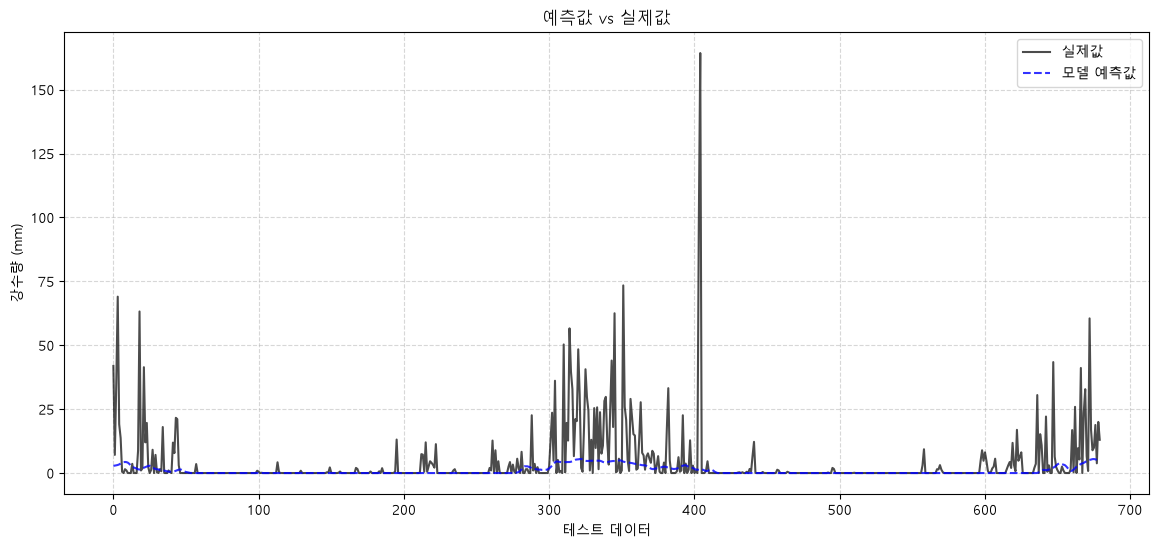

In [21]:
# 모델 학습
input_shape = (X_train.shape[1], X_train.shape[2])
deep_model = build_deep_model(input_shape)

early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("=== 베이스라인 모델 학습 시작 ===")
deep_history = deep_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 모델 평가
eval_results = deep_model.evaluate(X_test, y_test, verbose=0)
print(f"평가 완료: Loss(MAE): {eval_results[0]:.4f}, MSE: {eval_results[1]:.4f}, MAE: {eval_results[2]:.4f}")

pred_scaled = deep_model.predict(X_test, verbose=0)
pred_real = scaler_target.inverse_transform(pred_scaled)
y_test_real = scaler_target.inverse_transform(y_test)

# 결과 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label='실제값', color='black', linewidth=1.5, alpha=0.7)
plt.plot(pred_real, label='모델 예측값', color='blue', linestyle='--', alpha=0.8)

plt.title('예측값 vs 실제값')
plt.xlabel('테스트 데이터')
plt.ylabel('강수량 (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [22]:
# 모델이 비가 안오는 날이 압도적으로 많아 무조건 0으로 예측해서
# MAE(절대 오차) 총합을 낮추도록 학습이 되어 발생한 문제
# 또한, 층이 깊어져 희소한 폭우 패턴을 파악하지 못해고 기울기 소실된 것으로 확인되었다.
# 따라서 앞서 하기로 했던 타겟 데이터를 로그 변환을 먼저 수행한다.

=== 베이스라인 모델 학습 시작 (로그 적용) ===
Epoch 1/50


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0388 - mae: 0.0388 - mse: 0.0056 - val_loss: 0.0386 - val_mae: 0.0386 - val_mse: 0.0076
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0291 - mae: 0.0291 - mse: 0.0050 - val_loss: 0.0364 - val_mae: 0.0364 - val_mse: 0.0071
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0278 - mae: 0.0278 - mse: 0.0049 - val_loss: 0.0379 - val_mae: 0.0379 - val_mse: 0.0076
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0277 - mae: 0.0277 - mse: 0.0051 - val_loss: 0.0376 - val_mae: 0.0376 - val_mse: 0.0075
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0273 - mae: 0.0273 - mse: 0.0050 - val_loss: 0.0350 - val_mae: 0.0350 - val_mse: 0.0067
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0272 - mae: 0.0272 - mse: 0.0050 - val_loss: 0.0344 - val_mae: 0.0344 - val_mse: 0.0064
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0271 - mae: 0.0271 - mse: 0.0049 - val_loss: 0.0353 - val_mae:

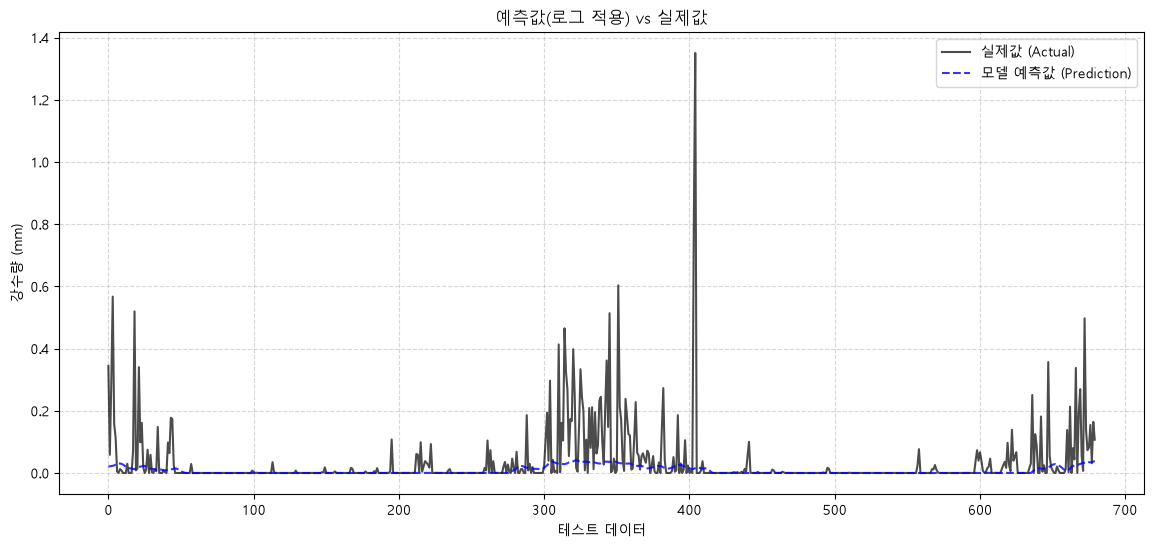

In [23]:
#  로그 log1p로 극단적인 스케일 차이를 줄여주기
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

input_shape = (X_train.shape[1], X_train.shape[2])
deep_model = build_deep_model(input_shape)

# 모델 학습
print("=== 베이스라인 모델 학습 시작 (로그 적용) ===")
deep_history = deep_model.fit(
    X_train, y_train_log,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 모델 평가 및 예측값 역변환
eval_results = deep_model.evaluate(X_test, y_test_log, verbose=0)
print(f"평가 완료: Loss(MAE): {eval_results[0]:.4f}, MSE: {eval_results[1]:.4f}, MAE: {eval_results[2]:.4f}")

pred_log = deep_model.predict(X_test, verbose=0)

pred_real = np.expm1(pred_log)
y_test_real = np.expm1(y_test_log)

# 결과 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label='실제값 (Actual)', color='black', linewidth=1.5, alpha=0.7)
plt.plot(pred_real, label='모델 예측값 (Prediction)', color='blue', linestyle='--', alpha=0.8)

plt.title('예측값(로그 적용) vs 실제값')
plt.xlabel('테스트 데이터')
plt.ylabel('강수량 (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
# 성능이 나아지지 않아서 마지막으로 분류 + 회귀 파이프라인트로
# 비가 오는지 안오는지 맞히는 모델로 비를 예측하고
# 이후 비가 온다면 몇 mm가 오는지 예측하는 분류 + 회귀 모델로 변경
# 분류에서는 이전에 제외했던 preciptype를 타겟으로 사용하기로 결정

In [25]:
# preciptype (강수 형태) 추가
new_features = features + ["preciptype"]

new_data = df[new_features + [target]].copy()

# 데이터 분할 train, test (시계열이라 스플릿)
new_train_size = int(len(new_data) * 0.8)
new_train_df = new_data[:new_train_size].copy()
new_test_df = new_data[new_train_size:].copy()

# 범주형 변수 원핫 인코딩
new_train_df["preciptype"] = new_train_df["preciptype"].fillna("none")
new_test_df["preciptype"] = new_test_df["preciptype"].fillna("none")

# OneHotEncoder 적용
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
train_precip_encoded = encoder.fit_transform(new_train_df[["preciptype"]])
test_precip_encoded = encoder.transform(new_test_df[["preciptype"]])

# 인코딩된 배열 데이터 프레임으로 변환
encoded_col_names = encoder.get_feature_names_out(["preciptype"])
train_precip_df = pd.DataFrame(train_precip_encoded, columns=encoded_col_names, index=new_train_df.index)
test_precip_df = pd.DataFrame(test_precip_encoded, columns=encoded_col_names, index=new_test_df.index)

# 원래의 preciptype을 지우고 인코딩된 새 칼럼들을 병합
new_train_df = pd.concat([new_train_df.drop(columns=["preciptype"]), train_precip_df], axis=1)
new_test_df = pd.concat([new_test_df.drop(columns=["preciptype"]), test_precip_df], axis=1)

In [26]:
# 수치형 피처 및 타겟 스케일링
new_numeric_cols = [
    "temp", "dew", "humidity", "sealevelpressure", "cloudcover",
    "precipprob", "precipcover", "windspeed", "windgust", "winddir"
]
new_target_col = "precipitation"

# 타겟 로그 변환 (극심한 편차 완화)
new_train_df[new_target_col] = np.log1p(new_train_df[new_target_col])
new_test_df[new_target_col] = np.log1p(new_test_df[new_target_col])

# 피처 스케일링
new_scaler_feature = MinMaxScaler()
new_train_df[new_numeric_cols] = new_scaler_feature.fit_transform(new_train_df[new_numeric_cols])
new_test_df[new_numeric_cols] = new_scaler_feature.transform(new_test_df[new_numeric_cols])

# 타겟 스케일링 (나중에 예측값 복구를 위한 별도의 스케일러 사용)
new_scaler_target = MinMaxScaler()
new_train_df[new_target_col] = new_scaler_target.fit_transform(new_train_df[[new_target_col]])
new_test_df[new_target_col] = new_scaler_target.transform(new_test_df[[new_target_col]])

In [27]:
# 시퀀스 데이터셋 생성
def create_new_sequences(data, target_col, feature_cols, time_steps=7):
    X, y = [], []
    data_values = data[feature_cols].values
    target_values = data[target_col].values
    
    for i in range(len(data) - time_steps):
        X.append(data_values[i:(i + time_steps)])
        y.append(target_values[i + time_steps])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

new_feature_cols = [col for cols in new_train_df.columns if col != new_target_col]
time_steps = 7

X_train, y_train = create_new_sequences(new_train_df, new_target_col, new_feature_cols, time_steps)
X_test, y_test = create_new_sequences(new_test_df, new_target_col, new_feature_cols, time_steps)

In [28]:
## 2단계 파이프라인 (분류 + 회귀)
# 타겟이 스케일링 되어있으므로 비가 왔는지 판단하기 위해 원래 단위(mm)로 임시 복원
y_train_real = new_scaler_target.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_real = new_scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 기준 설정 (0.1mm 초과가 비가 온것으로 정의)
rain_threshold = 0.1
y_train_class = (y_train_real > rain_threshold).astype(int)

# [1단계] 비 여부 이진 분류 모델 학습 (Rain / No Rain)
print("=== 1단계 : 비 여부 분류 모델 학습 시작 ===")
model_class = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_class.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stopping_cls = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model_class.fit(
    X_train, y_train_class,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_cls],
    verbose=1
)

print("=== 2단계 : 강수량 회귀 모델 학습 시작 ===")
train_rain_idx = np.where(y_train_real > rain_threshold)[0]
X_train_rain = X_train[train_rain_idx]
y_train_rain = y_train[train_rain_idx] # 학습을 위해 스케일링된 값 그대로 사용

model_reg = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation="elu"),
    Dense(1, activation="relu") # 강수량 예측
])

optimizer = Adam(learning_rate=0.0005)
model_reg.compile(optimizer=optimizer, loss="mse", metrics=["mse", "mae"])
early_stopping_reg = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# 학습 중 손실이 안줄어들면 학습률을 절반씩 낮춰주는 콜백
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # 학습률을 기존의 절반으로
    patience=3, # 3번 동안 개선이 없으면 발동
    min_lr=1e-6, # 마지노선 학습법 (여기까지만 내려올 수 있음)
    verbose=1
)

history_reg = model_reg.fit(
    X_train_rain, y_train_rain,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_reg, reduce_lr],
    verbose=1
)

print("최종 훈련 Loss:", history_reg.history['loss'][-1])
print("최종 검증 Loss (val_loss):", history_reg.history['val_loss'][-1])

## 결합 추론 및 원래 단위(mm)로 복원
# 1단계 : 테스트 데이터가 비가 올 확률 예측
pred_prob = model_class.predict(X_test, verbose=0).flatten()

# 2단계 : 테스트 데이터의 강수략 예측 (스케일링된 상태)
pred_amount_scaled = model_reg.predict(X_test, verbose=0)

# 스케일링된 예측값을 원래 단위(mm)로 복원
pred_amount_log = new_scaler_target.inverse_transform(pred_amount_scaled).flatten()
pred_amount_real = np.expm1(pred_amount_log)

# 결합 비가 올 확률이 1.5% 이상이면 2단계 회귀 예측값을 사용. 아니면 0mm
decision_threshold = 0.15
final_pred = np.where(pred_prob >= decision_threshold, pred_amount_real, 0.0)

# 음수값 예측 방지 (최소값 0)
final_pred = np.clip(final_pred, 0, None)  # 음수 

=== 1단계 : 비 여부 분류 모델 학습 시작 ===
Epoch 1/30


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6317 - loss: 0.6897 - val_accuracy: 0.5560 - val_loss: 0.6904
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6832 - val_accuracy: 0.5560 - val_loss: 0.6885
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6777 - val_accuracy: 0.5560 - val_loss: 0.6874
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6732 - val_accuracy: 0.5560 - val_loss: 0.6869
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6698 - val_accuracy: 0.5560 - val_loss: 0.6869
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6670 - val_accuracy: 0.5560 - val_loss: 0.6873
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6648 - val_accuracy: 0.5560 - val_loss: 0.6879
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6317 - loss: 0.6631 - val_accuracy: 0.5560 - val_loss: 0.6887
Epo

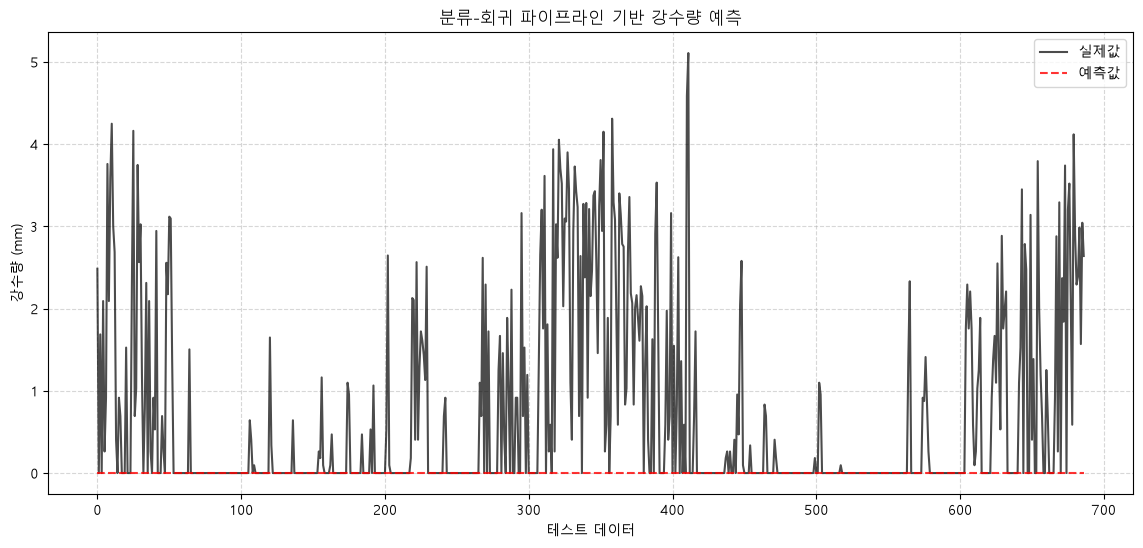

In [29]:
# 최종 결과 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="실제값", color="black", linewidth=1.5, alpha=0.7)
plt.plot(final_pred, label="예측값", color="red", linestyle="--", alpha=0.8)

plt.title("분류-회귀 파이프라인 기반 강수량 예측")
plt.xlabel('테스트 데이터')
plt.ylabel('강수량 (mm)')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [30]:
# 1. 데이터 준비
new_features = features + ["preciptype"]
new_data = df[new_features + [target]].copy()

# 시계열 데이터 분할
new_train_size = int(len(new_data) * 0.8)
new_train_df = new_data[:new_train_size].copy()
new_test_df = new_data[new_train_size:].copy()

# 범주형 변수 처리
new_train_df["preciptype"] = new_train_df["preciptype"].fillna("none")
new_test_df["preciptype"] = new_test_df["preciptype"].fillna("none")

# 원핫 인코딩
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
train_precip_encoded = encoder.fit_transform(new_train_df[["preciptype"]])
test_precip_encoded = encoder.transform(new_test_df[["preciptype"]])

# 원핫 인코딩한 칼럼들 데이터프레임으로 변환
encoded_col_names = encoder.get_feature_names_out(["preciptype"])
train_precip_df = pd.DataFrame(train_precip_encoded, columns=encoded_col_names, index=new_train_df.index)
test_precip_df = pd.DataFrame(test_precip_encoded, columns=encoded_col_names, index=new_test_df.index)

# 원핫 인코딩 결과를 원래 데이터에 병합, 원래 있던 preciptype은 삭제
new_train_df = pd.concat([new_train_df.drop(columns=["preciptype"]), train_precip_df], axis=1)
new_test_df = pd.concat([new_test_df.drop(columns=["preciptype"]), test_precip_df], axis=1)

In [ ]:
new_numeric_cols = [
    "temp", "dew", "humidity", "sealevelpressure", "cloudcover",
    "precipprob", "precipcover", "windspeed", "windgust", "winddir"
]
new_target_col = "precipitation"

new_scaler_feature = MinMaxScaler()
new_train_df[new_numeric_cols] = new_scaler_feature.fit_transform(new_train_df[new_numeric_cols])
new_test_df[new_numeric_cols] = new_scaler_feature.transform(new_test_df[new_numeric_cols])

# 2. 타겟 로그 변환 (0~170mm의 극단적 격차를 압축)
new_train_df[new_target_col] = np.log1p(new_train_df[new_target_col])
new_test_df[new_target_col] = np.log1p(new_test_df[new_target_col])

new_scaler_target = MinMaxScaler()
new_train_df[new_target_col] = new_scaler_target.fit_transform(new_train_df[[new_target_col]])
new_test_df[new_target_col] = new_scaler_target.transform(new_test_df[[new_target_col]])

def create_sequences(data, target_col, feature_cols, time_steps=7):
    X, y = [], []
    data_values = data[feature_cols].values
    target_values = data[target_col].values
    
    for i in range(len(data) - time_steps):
        X.append(data_values[i:(i + time_steps)])
        y.append(target_values[i + time_steps])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

new_feature_cols = [col for col in new_train_df.columns if col != new_target_col]
time_steps = 7

X_train, y_train = create_sequences(new_train_df, new_target_col, new_feature_cols, time_steps)
X_test, y_test = create_sequences(new_test_df, new_target_col, new_feature_cols, time_steps)

# 4. 단일 LSTM 회귀 모델 구축 (분류 단계 제거)
print("=== 단일 강수량 예측 LSTM 모델 학습 시작 ===")
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="elu"),
    Dense(1, activation="relu") # 강수량은 음수가 없으므로 relu로 0 이상 보장
])

# 폭우 Outlier에 무너지지 않도록 Huber Loss 사용
model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss=Huber(delta=1.0), 
    metrics=["mae"]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 5. 추론 및 원래 단위(mm)로 복원
pred_scaled = model.predict(X_test, verbose=0)
pred_log = new_scaler_target.inverse_transform(pred_scaled).flatten()
final_pred = np.expm1(pred_log)  # log1p 역변환
final_pred = np.clip(final_pred, 0, None)

print("최소 예측값:", final_pred.min(), "/ 최대 예측값:", final_pred.max(), "/ 평균:", final_pred.mean())

=== 단일 강수량 예측 LSTM 모델 학습 시작 ===
Epoch 1/50


c:\Project\dl\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0230 - mae: 0.1359 - val_loss: 0.0199 - val_mae: 0.1314 - learning_rate: 0.0010
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0201 - mae: 0.1283 - val_loss: 0.0202 - val_mae: 0.1314 - learning_rate: 0.0010
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0195 - mae: 0.1280 - val_loss: 0.0200 - val_mae: 0.1277 - learning_rate: 0.0010
Epoch 4/50
53/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0197 - mae: 0.1293
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0194 - mae: 0.1276 - val_loss: 0.0199 - val_mae: 0.1339 - learning_rate: 0.0010
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - mae: 0.1295 - val_loss: 0.0207 - val_mae: 0.1328 - learning_rate: 5.0000e-04
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - mae: 0.1302 - val_loss: 0.0202 - val_mae: 0.1333 - learning_rate: 5.0000e-04
Epoch 7/50
54/70 ━━

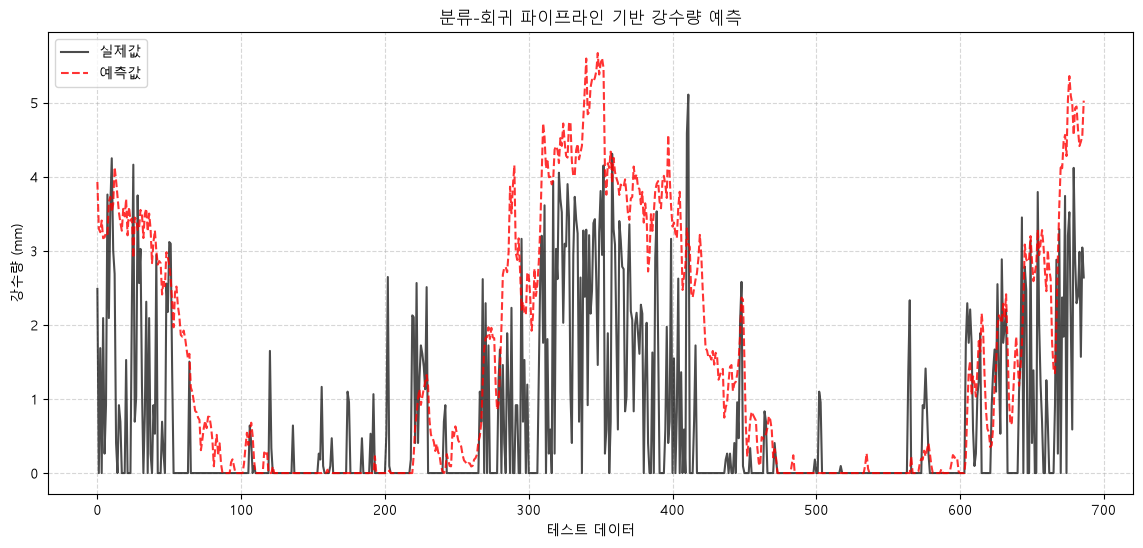

In [32]:
# 최종 결과 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="실제값", color="black", linewidth=1.5, alpha=0.7)
plt.plot(final_pred, label="예측값", color="red", linestyle="--", alpha=0.8)

plt.title("분류-회귀 파이프라인 기반 강수량 예측")
plt.xlabel('테스트 데이터')
plt.ylabel('강수량 (mm)')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [39]:
# 모델 저장 및 스케일러 저장
import os

os.makedirs("models", exist_ok=True)
os.makedirs("scalers", exist_ok=True)
os.makedirs("encoders", exist_ok=True)

# 1. 모델 저장 (LSTM)
model.save("models/precipitation_lstm_model.keras")

# 2. 스케일러 저장
joblib.dump(new_scaler_feature, "scalers/scaler_feature.pkl")
joblib.dump(new_scaler_target, "scalers/scaler_target.pkl")

# 3. 인코더 저장
joblib.dump(encoder, "encoders/encoder.pkl")

print("모델과 스케일러, 인코더 저장 완료")

모델과 스케일러, 인코더 저장 완료
